# Framingham Heart Disease Data Exploration
This notebook explores the raw data set to determine how the data should be cleaned.

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pygam import LogisticGAM, s, f

In [5]:
df = pd.read_csv("../data/framingham.csv")
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [7]:
df.describe(include='all')

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [8]:
df.isna().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [9]:
df["TenYearCHD"].value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

In [11]:
df.dtypes

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

In [14]:
df["TenYearCHD"].value_counts(normalize=True)

TenYearCHD
0    0.848113
1    0.151887
Name: proportion, dtype: float64

<Axes: xlabel='TenYearCHD', ylabel='count'>

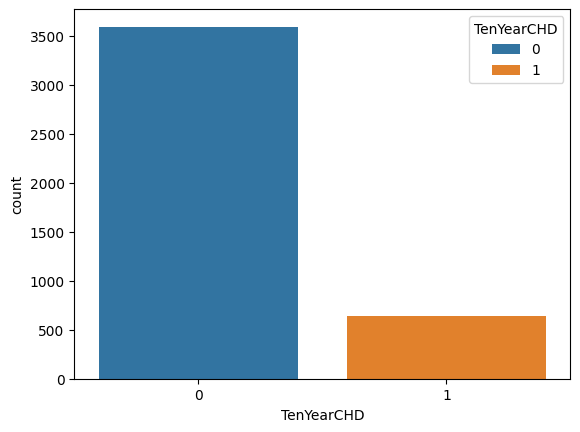

In [15]:
sns.countplot(data = df, x = "TenYearCHD", hue = "TenYearCHD")

<Axes: >

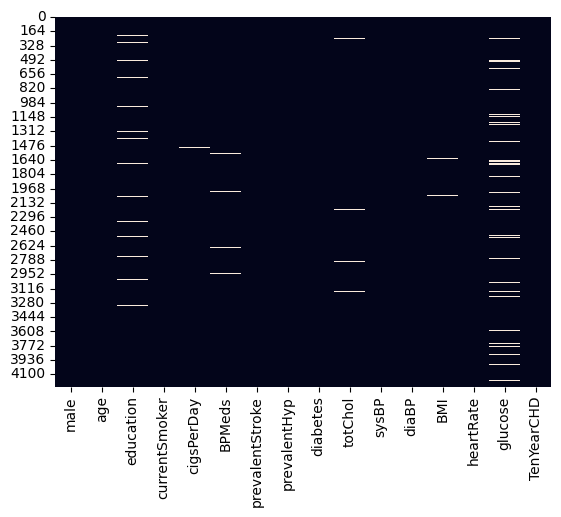

In [19]:
# missing value map
# shows missing values by column and row
sns.heatmap(df.isna(), cbar=False)

array([[<Axes: title={'center': 'male'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'currentSmoker'}>],
       [<Axes: title={'center': 'cigsPerDay'}>,
        <Axes: title={'center': 'BPMeds'}>,
        <Axes: title={'center': 'prevalentStroke'}>,
        <Axes: title={'center': 'prevalentHyp'}>],
       [<Axes: title={'center': 'diabetes'}>,
        <Axes: title={'center': 'totChol'}>,
        <Axes: title={'center': 'sysBP'}>,
        <Axes: title={'center': 'diaBP'}>],
       [<Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'heartRate'}>,
        <Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'TenYearCHD'}>]], dtype=object)

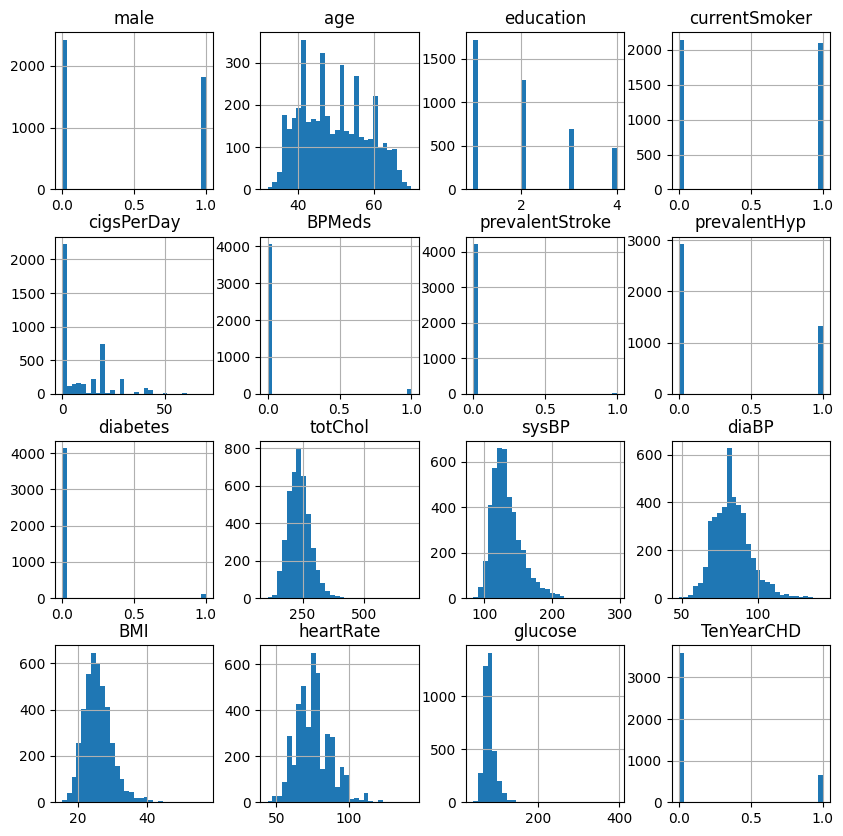

In [20]:
df.hist(figsize=(10,10))

In [29]:
df["prevalentStroke"].value_counts()

prevalentStroke
0    4215
1      25
Name: count, dtype: int64

In [30]:
df["diabetes"].value_counts()

diabetes
0    4131
1     109
Name: count, dtype: int64

In [32]:
df["BPMeds"].value_counts()

BPMeds
0.0    4063
1.0     124
Name: count, dtype: int64

In [36]:
df["prevalentHyp"].value_counts()

prevalentHyp
0    2923
1    1317
Name: count, dtype: int64

<Axes: >

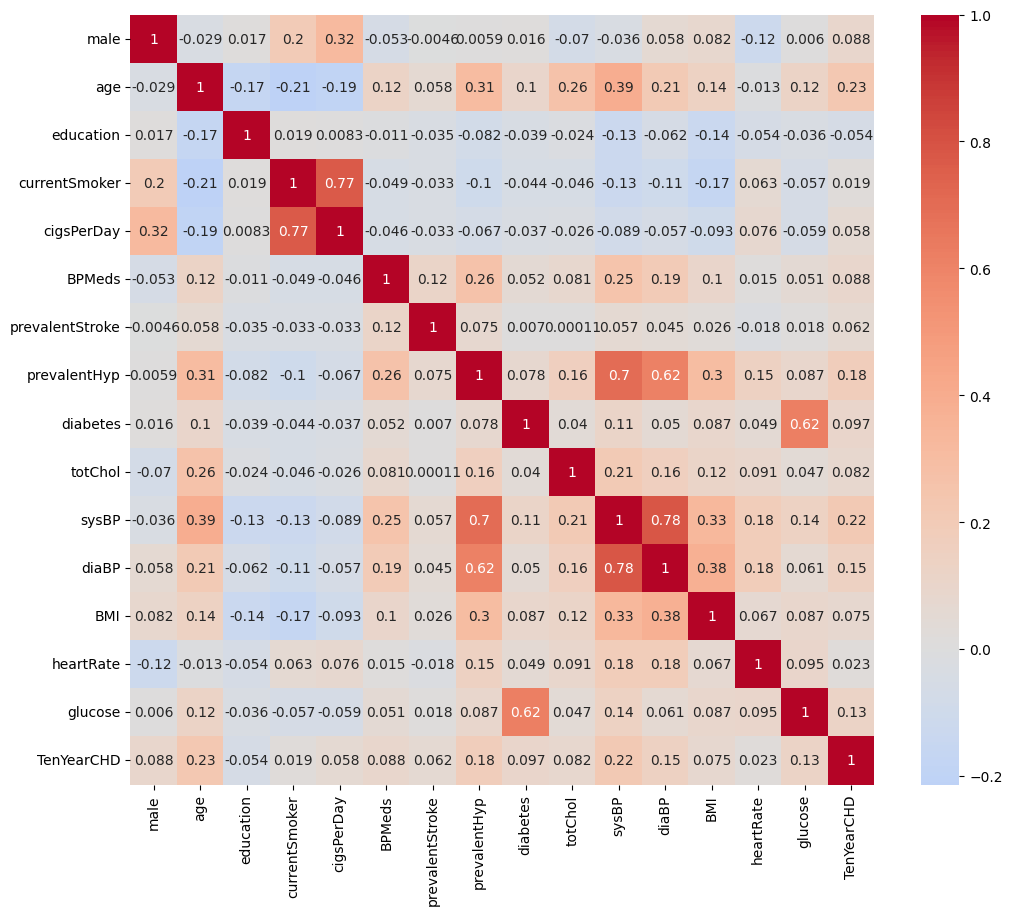

In [35]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=True)

### Correlation
It doesn't look like any of the predictor variables are strongly correlated with TenYearCHD

<Axes: xlabel='age', ylabel='totChol'>

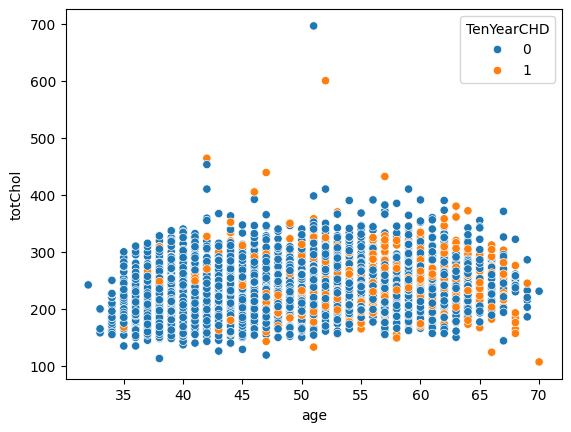

In [37]:
sns.scatterplot(data=df, x="age", y="totChol", hue="TenYearCHD")

<Axes: xlabel='age', ylabel='sysBP'>

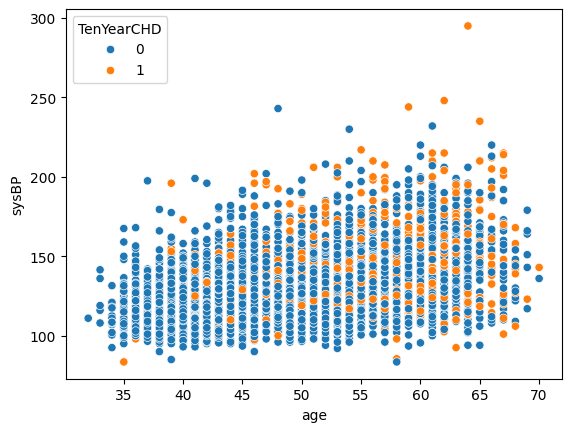

In [41]:
sns.scatterplot(data=df, x="age", y="sysBP", hue="TenYearCHD")

<Axes: xlabel='age', ylabel='BMI'>

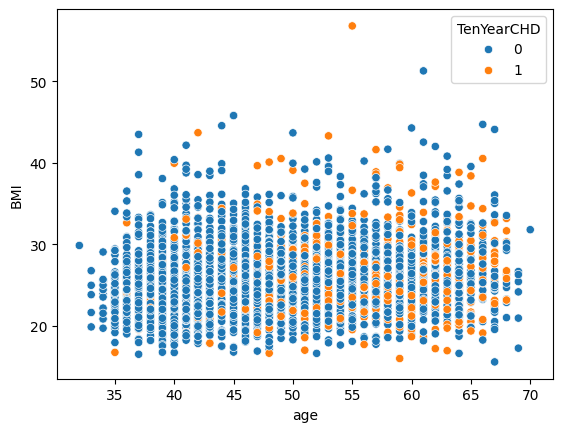

In [43]:
sns.scatterplot(data=df, x="age", y="BMI", hue="TenYearCHD")

<Axes: xlabel='TenYearCHD', ylabel='age'>

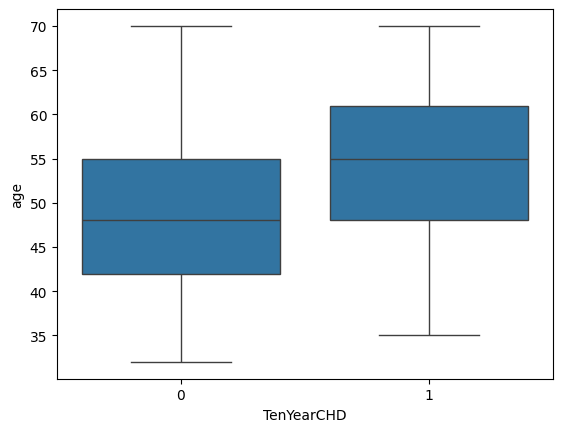

In [38]:
sns.boxplot(data=df, x="TenYearCHD", y="age")

<Axes: xlabel='TenYearCHD', ylabel='currentSmoker'>

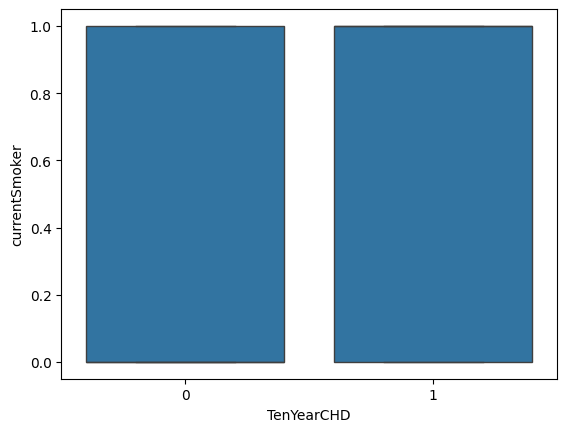

In [39]:
sns.boxplot(data=df, x="TenYearCHD", y="currentSmoker")

<Axes: xlabel='age', ylabel='TenYearCHD'>

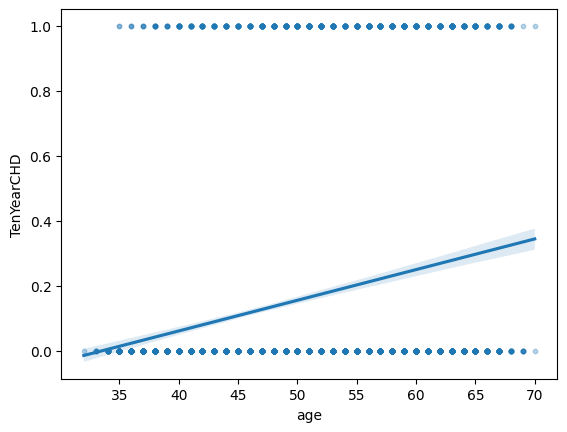

In [45]:
sns.regplot(data=df, x="age", y="TenYearCHD", scatter_kws={"s":10, "alpha":0.3})

<Axes: xlabel='sysBP', ylabel='TenYearCHD'>

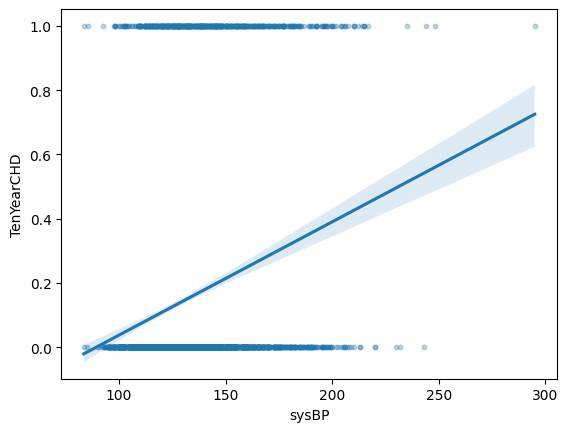

In [47]:
sns.regplot(data=df, x="sysBP", y="TenYearCHD", scatter_kws={"s":10, "alpha":0.3})

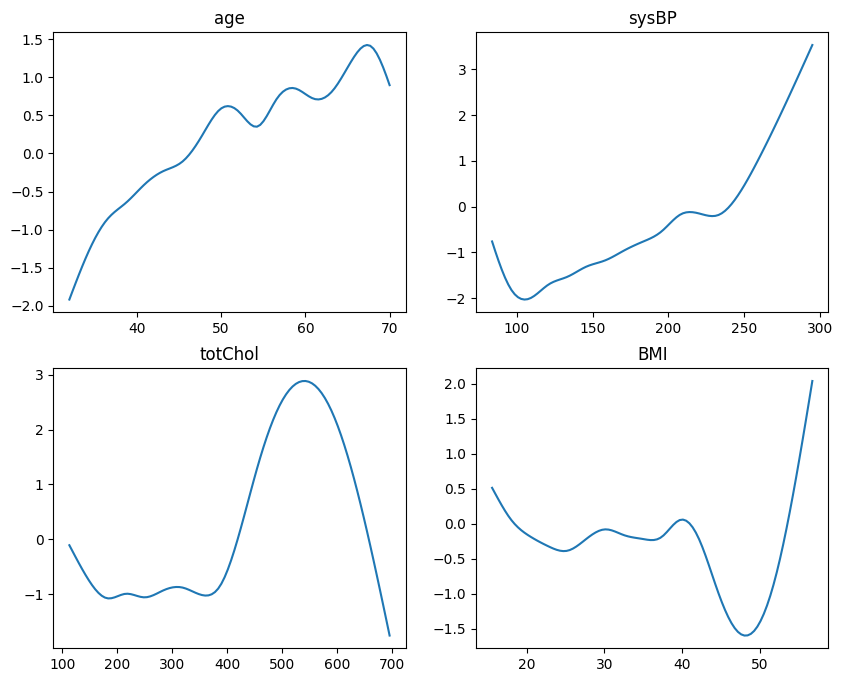

In [50]:
X = df[["age", "sysBP", "totChol", "BMI"]].dropna()
y = df.loc[X.index, "TenYearCHD"]

gam = LogisticGAM(s(0) + s(1) + s(2) + s(3)).fit(X, y)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axs.flatten()):
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.set_title(X.columns[i])